## Importing Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

## Load Dataset

In [3]:
df=pd.read_excel('Online retail.xlsx')
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


## Data Understanding

In [4]:
#Shape of dataset
print(df.shape)

(541909, 8)


In [5]:
#Columns names
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


In [6]:
#data types and non-null counts
missing=df.isnull().sum()
print('Missing Value:')
print(missing[missing>0])

Missing Value:
Description      1454
CustomerID     135080
dtype: int64


## Data Cleaning

In [7]:
#dropping missing rows in CustomerID
print('Rows before dropping missing CustomerID:',len(df))
df=df.dropna(subset=['CustomerID'])
print('Rows after dropping missing CustomerID:',len(df))

Rows before dropping missing CustomerID: 541909
Rows after dropping missing CustomerID: 406829


In [8]:
#Removing duplicate rows
print('Rows before removing duplicates:',len(df))
df=df.drop_duplicates()
print('Rows after removing duplicates:',len(df))

Rows before removing duplicates: 406829
Rows after removing duplicates: 401604


In [9]:
#Identify cancelled order (InvoiceNo starting with 'C')
cancelled = df[df['InvoiceNo'].astype(str).str.startswith('C')]
print('Cancelled orders:', len(cancelled))
print(cancelled[['InvoiceNo', 'Quantity', 'Description']].head(5))

Cancelled orders: 8872
    InvoiceNo  Quantity                       Description
141   C536379        -1                          Discount
154   C536383        -1   SET OF 3 COLOURED  FLYING DUCKS
235   C536391       -12    PLASTERS IN TIN CIRCUS PARADE 
236   C536391       -24  PACK OF 12 PINK PAISLEY TISSUES 
237   C536391       -24  PACK OF 12 BLUE PAISLEY TISSUES 


In [10]:
#Remove cancelled orders from dataset
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f"Rows after removing cancelled orders: {len(df)}")

Rows after removing cancelled orders: 392732


In [11]:
#Create sales column
df['Sales']=df['Quantity']*df['UnitPrice']

In [12]:
#Convert InvoiceDate to Datetime
df['InvoiceDate']= pd.to_datetime(df['InvoiceDate'])

In [13]:
# Extract Month and Day for time-based analysis
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

df['Month'] = df['InvoiceDate'].dt.month_name()
df['Day'] = df['InvoiceDate'].dt.day_name()

print("New columns added: Sales, Month, Day")
df[['InvoiceDate', 'Sales', 'Month', 'Day']].head(5)

New columns added: Sales, Month, Day


,InvoiceDate,Sales,Month,Day
0,2010-12-01 08:26:00,15.30,December,Wednesday
1,2010-12-01 08:26:00,20.34,December,Wednesday
2,2010-12-01 08:26:00,22.00,December,Wednesday
3,2010-12-01 08:26:00,20.34,December,Wednesday
4,2010-12-01 08:26:00,20.34,December,Wednesday


## Statistical Analysis

In [14]:
df[['Quantity','UnitPrice','Sales']].describe().round(2)

,Quantity,UnitPrice,Sales
count,392732.00,392732.00,392732.00
mean,13.15,3.13,22.63
std,181.59,22.24,311.08
min,1.00,0.00,0.00
25%,2.00,1.25,4.95
50%,6.00,1.95,12.39
75%,12.00,3.75,19.80
max,80995.00,8142.75,168469.60


In [15]:
# Total revenue in the dataset
total_revenue = df['Sales'].sum()
total_orders = df['InvoiceNo'].nunique()
total_customers = df['CustomerID'].nunique()
total_products = df['Description'].nunique()
total_countries = df['Country'].nunique()

print(f" Total Revenue     : {total_revenue:,.2f}")
print(f" Total Orders      : {total_orders:,}")
print(f" Unique Customers  : {total_customers:,}")
print(f" Unique Products   : {total_products:,}")
print(f" Countries Served  : {total_countries:,}")

 Total Revenue     : 8,887,208.89
 Total Orders      : 18,536
 Unique Customers  : 4,339
 Unique Products   : 3,877
 Countries Served  : 37


## Data Visualisation

### Sales Distribution

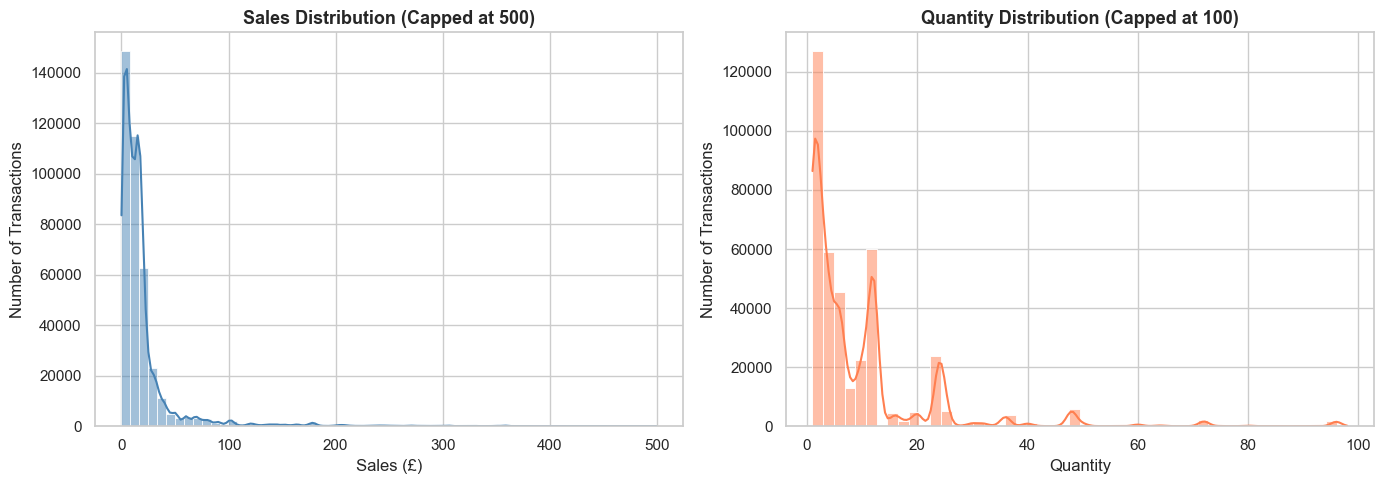

In [29]:
# Capping at 500 to show the true distribution (extreme outliers compress the chart)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[df['Sales'] < 500]['Sales'], bins=60, color='steelblue', kde=True, ax=axes[0])
axes[0].set_title('Sales Distribution (Capped at 500)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sales (£)')
axes[0].set_ylabel('Number of Transactions')

sns.histplot(df[df['Quantity'] < 100]['Quantity'], bins=50, color='coral', kde=True, ax=axes[1])
axes[1].set_title('Quantity Distribution (Capped at 100)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Quantity')
axes[1].set_ylabel('Number of Transactions')

plt.tight_layout()
plt.show()

>**Insight:** Most transactions are small-value (under £50), indicating a high volume of low-ticket purchases. A small number of bulk orders drive the upper tail.

### Quantity vs Sales

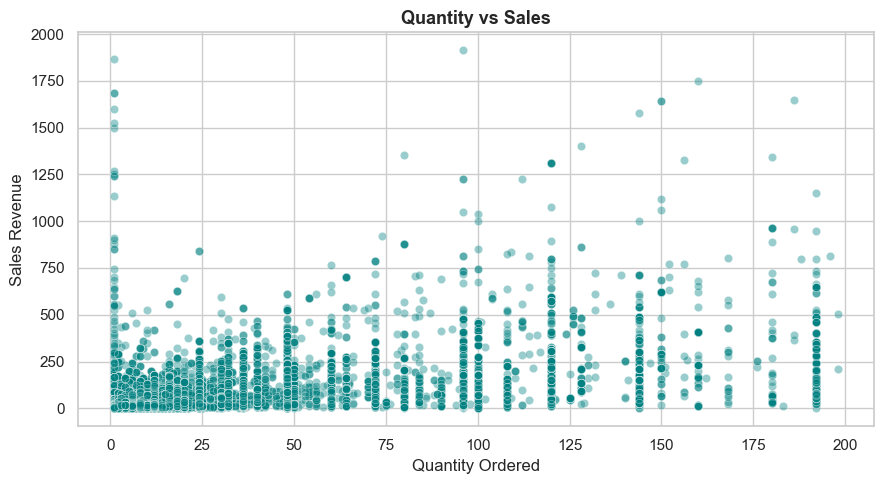

In [30]:
# Filter out extreme outliers for a cleaner scatter plot
df_plot = df[(df['Quantity'] < 200) & (df['Sales'] < 2000)]

plt.figure(figsize=(9, 5))
sns.scatterplot(x='Quantity', y='Sales', data=df_plot, alpha=0.4, color='teal')
plt.title('Quantity vs Sales', fontsize=13, fontweight='bold')
plt.xlabel('Quantity Ordered')
plt.ylabel('Sales Revenue')
plt.tight_layout()
plt.show()

>**Insight:** A clear positive relationship — as quantity increases, revenue increases. The spread suggests varying unit prices across products.

## Monthly Sales Trend

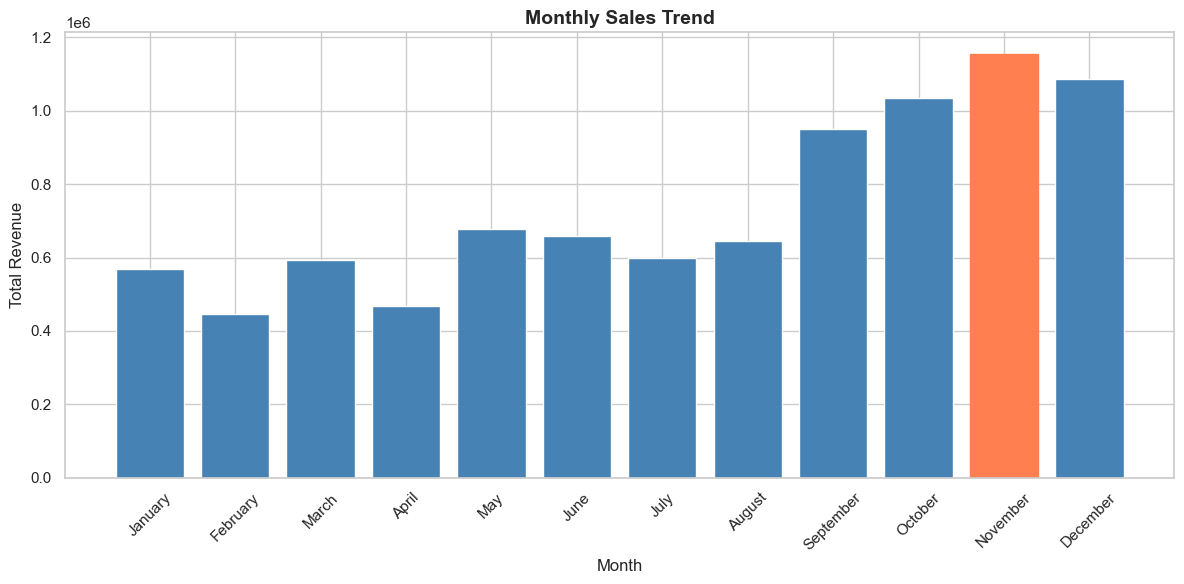


📈 Peak Sales Month: November — 1,156,205.61


In [32]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_sales = df.groupby('Month')['Sales'].sum().reindex(month_order)

plt.figure(figsize=(12, 6))
bars = plt.bar(monthly_sales.index, monthly_sales.values, color='steelblue', edgecolor='white')

# Highlight the peak month
peak_month = monthly_sales.idxmax()
for bar, month in zip(bars, monthly_sales.index):
    if month == peak_month:
        bar.set_color('coral')

plt.title('Monthly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\n📈 Peak Sales Month: {peak_month} — {monthly_sales[peak_month]:,.2f}")

> **Insight:** Sales peak sharply in **November**, driven by pre-Christmas shopping. Revenue drops significantly in January and February — typical post-holiday slowdown. The business should plan inventory and marketing campaigns around Q4.

 ## Sales by Day of Week

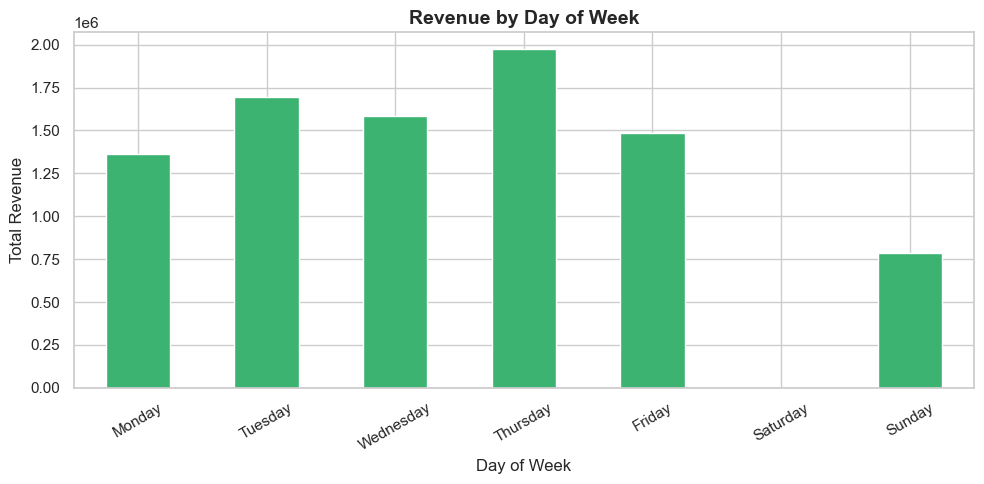


📅 Highest Revenue Day: Thursday — 1,973,015.73


In [21]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

daily_sales = df.groupby('Day')['Sales'].sum().reindex(day_order)

plt.figure(figsize=(10, 5))
daily_sales.plot(kind='bar', color='mediumseagreen', edgecolor='white')
plt.title('Revenue by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(f"\n📅 Highest Revenue Day: {daily_sales.idxmax()} — {daily_sales.max():,.2f}")

> **Insight:** Thursday and Tuesday are the highest revenue days. Sunday shows near-zero sales — likely because this is a B2B-oriented retailer that doesn't trade over weekends.

###  Top 10 Best-Selling Products

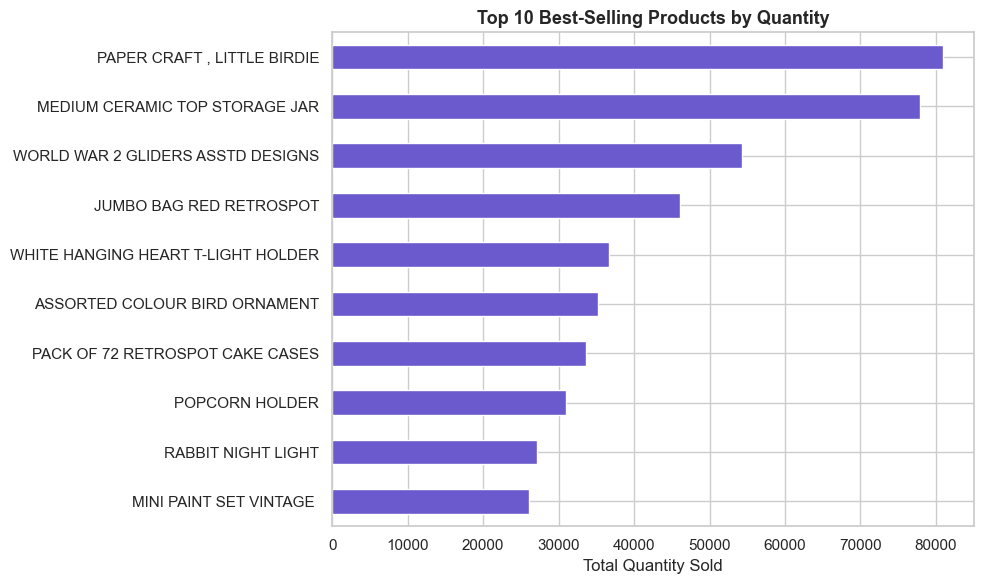

In [22]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
top_products.plot(kind='barh', color='slateblue', edgecolor='white')
plt.title('Top 10 Best-Selling Products by Quantity', fontsize=13, fontweight='bold')
plt.xlabel('Total Quantity Sold', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()

> **Insight:** The top products are primarily small decorative and gift items — consistent with the retailer's profile as a UK-based giftware wholesaler. These items should always be kept well-stocked.

###  Top Countries by Revenue

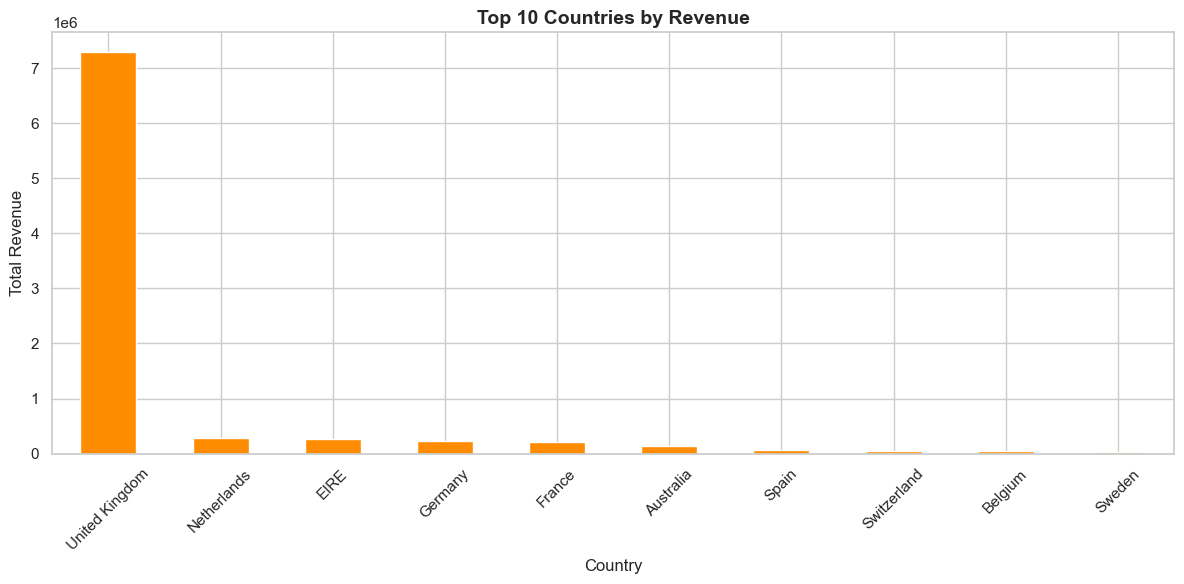

In [23]:
country_sales = df.groupby('Country')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
country_sales.plot(kind='bar', color='darkorange', edgecolor='white')
plt.title('Top 10 Countries by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> **Insight:** The UK dominates revenue — expected since this is a UK-based retailer. Among international markets, **Netherlands, EIRE (Ireland), and Germany** are the strongest, indicating good export potential to Europe.

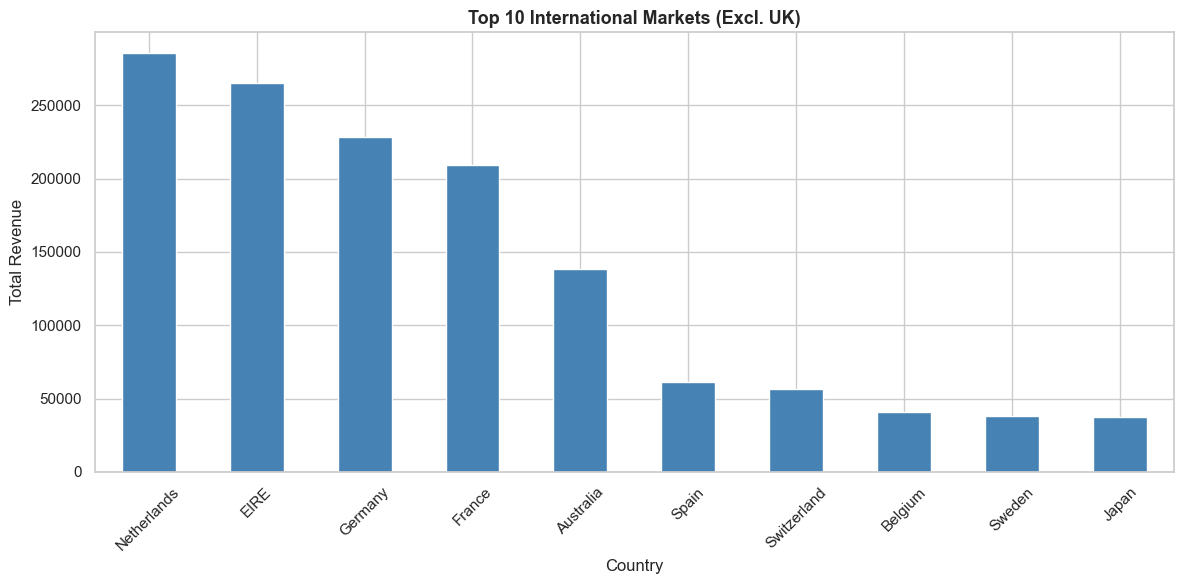

In [33]:
# Exclude UK to better see international performance
country_sales_intl = df[df['Country'] != 'United Kingdom'].groupby('Country')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
country_sales_intl.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 10 International Markets (Excl. UK)', fontsize=13, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> **Insight:** Netherlands and EIRE lead international sales. Expanding marketing efforts in these regions could significantly grow cross-border revenue.

###  Top 10 Customers by Revenue

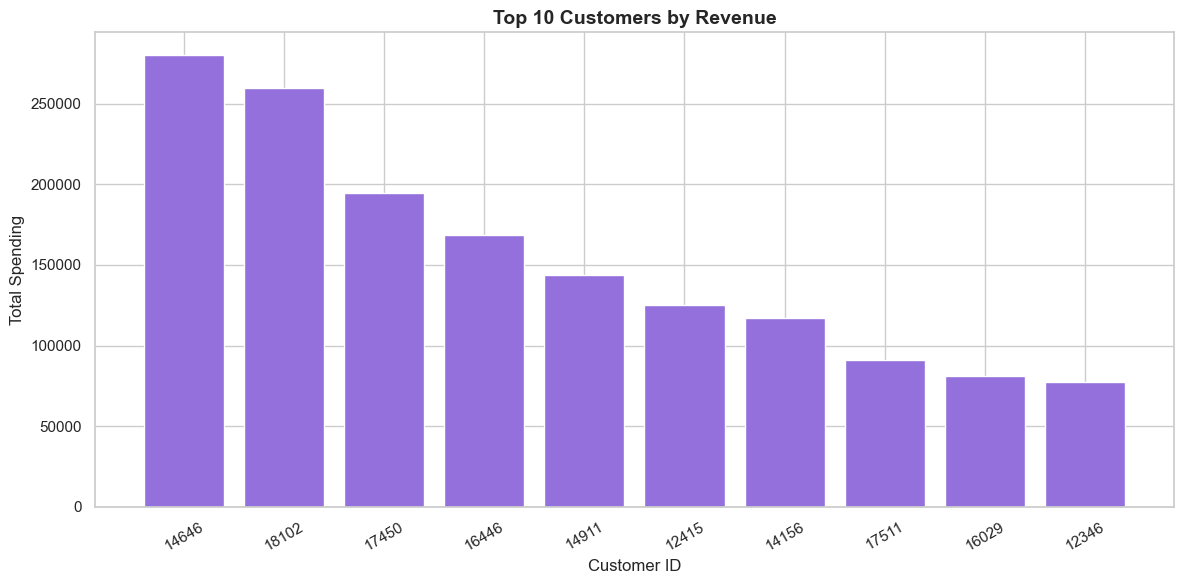


🏆 Top Customer Revenue: 280,206.02


In [25]:
top_customers = df.groupby('CustomerID')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()
top_customers['CustomerID'] = top_customers['CustomerID'].astype(int).astype(str)

plt.figure(figsize=(12, 6))
plt.bar(top_customers['CustomerID'], top_customers['Sales'], color='mediumpurple', edgecolor='white')
plt.title('Top 10 Customers by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Customer ID', fontsize=12)
plt.ylabel('Total Spending', fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(f"\n🏆 Top Customer Revenue: {top_customers['Sales'].iloc[0]:,.2f}")

> **Insight:** The top customer alone contributes significantly more than others — a classic **Pareto (80/20) pattern**. A loyalty or retention programme targeting these high-value customers would protect a large portion of revenue.

### Outlier Detection

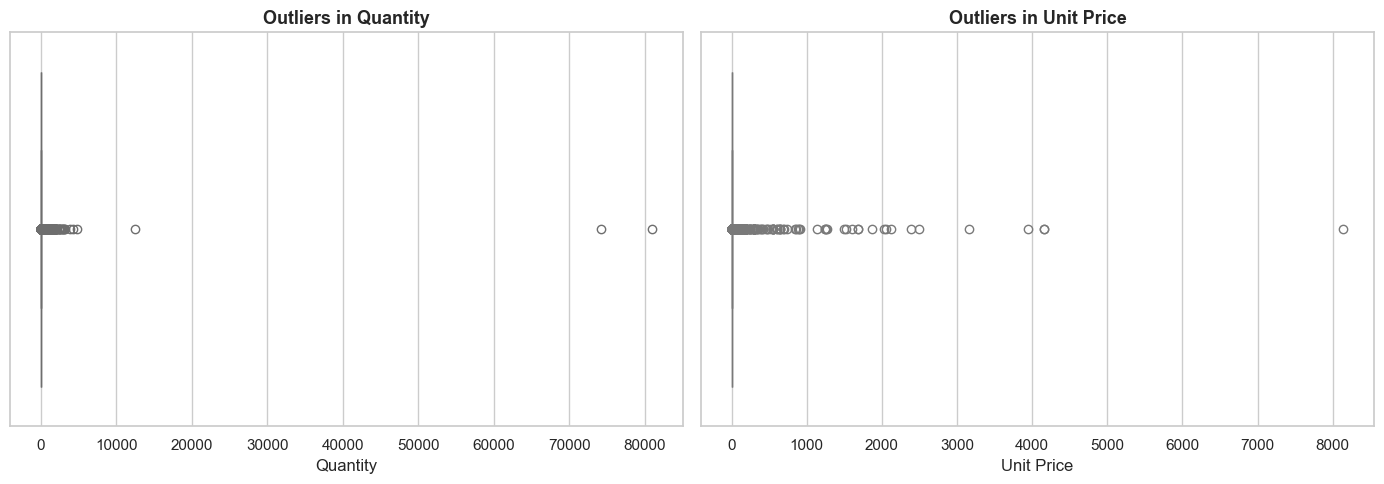

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x=df['Quantity'], color='lightcoral', ax=axes[0])
axes[0].set_title('Outliers in Quantity', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Quantity')

sns.boxplot(x=df['UnitPrice'], color='lightblue', ax=axes[1])
axes[1].set_title('Outliers in Unit Price', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Unit Price')

plt.tight_layout()
plt.show()

> **Insight:** Both Quantity and UnitPrice have significant outliers. These likely represent **bulk wholesale orders** rather than errors — a characteristic of B2B retail. These records were retained since they represent real business transactions.

##  Correlation Heatmap

A correlation heatmap shows how strongly numerical variables are related to each other.  
Values range from **-1** (opposite relationship) to **+1** (perfect relationship). **0** means no relationship.

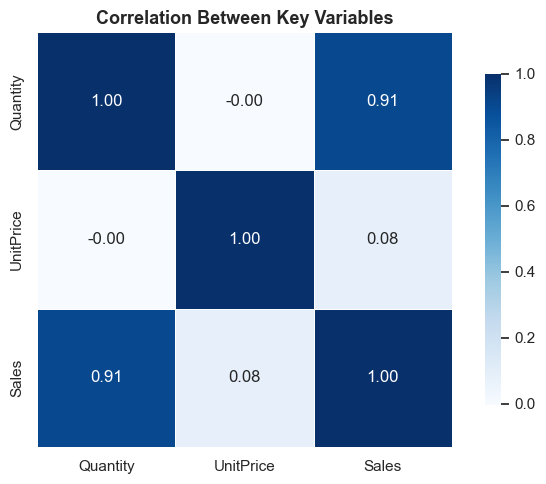

           Quantity  UnitPrice  Sales
Quantity       1.00      -0.00   0.91
UnitPrice     -0.00       1.00   0.08
Sales          0.91       0.08   1.00


In [27]:
plt.figure(figsize=(7, 5))
correlation = df[['Quantity', 'UnitPrice', 'Sales']].corr()

sns.heatmap(correlation, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Between Key Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(correlation.round(2))

> **Insight:**  
> - **Sales vs Quantity (strong positive):** Expected — Sales = Quantity × Price, so they naturally move together.  
> - **UnitPrice vs Quantity (weak/negative):** Customers don't buy significantly more of an item just because it's cheaper — consistent with B2B bulk purchasing behaviour where order quantity is driven by business need, not price sensitivity.

##  Key Findings & Business Recommendations

---

### 📊 Key Findings

| # | Finding |
|---|---------|
| 1 | **November is the peak sales month** — driven by pre-Christmas demand |
| 2 | **Thursday and Tuesday** generate the highest weekday revenue |
| 3 | **Sunday sales are near zero** — confirming a B2B wholesale business model |
| 4 | **UK dominates revenue** but Netherlands, EIRE, and Germany are strong international markets |
| 5 | **Top 10 customers** contribute a disproportionately large share of total revenue (Pareto principle) |
| 6 | **Small decorative and giftware items** are the best-selling products by volume |
| 7 | **Outliers in Quantity** represent genuine bulk orders, not data errors |

---

### 💡 Business Recommendations

1. **Seasonal Strategy:** Launch Q4 promotions and increase inventory from October to capture peak demand in November.
2. **Customer Retention:** Identify and create a loyalty programme for the top 20% of customers who drive 80% of revenue.
3. **International Expansion:** Invest in targeted marketing for Netherlands, Germany, and EIRE — the strongest export markets.
4. **Weekend Engagement:** Explore B2C channels or weekend promotions since Sunday revenue is virtually zero.
5. **Pricing Analysis:** Since UnitPrice has little impact on Quantity ordered, value-based pricing strategies can be tested without risking volume loss.

---
